In [1]:
%load_ext autoreload
%autoreload 2

# Facility location problems examples #

In the following, a couple of examples of using the solver will be presented.

**The software is meant for didactic purposes only.**

*v1.5 - Last update: 2025-05-02*


Import the required data structures and functions.
Press shift + enter in each cell to run the commands, or click on Run in the command bar.

In [2]:
from data_structures import Warehouse, Customer, calculate_dm, show_geo_map, show_data
from netopt_utils import plot_map


Import the solver's user interface

In [3]:
from netopt_ui import netopt_ui

The following cells contain the original date of the problem. You can copy and paste it to other cells, and change the values to test diffent alternatives. 

**ATTENTION** the solver expects to find the problem's data in the _warehouses_ and _customers_ variables, so you must keep those names.

In [4]:
# These are the candidate locations (including warehouses already active)
# You can change this data, or add/remove rows if you need to. Anyway, pay attention and use the same format reported below.

# ATTENTION: the index of the dictionary (i.e. the first number before the colon (:) and the name of the warehouse MUST BE unique)
# i.e. the following are not valid:
# warehouses_data = {
#    1: Warehouse(name="W1", city="Milan", state="Italy", zipcode="", latitude=0, longitude=0, capacity=1000, fixed_cost=1000),
#    1: Warehouse(name="W2", city="Rome", state="Italy", zipcode="", latitude=0, longitude=0, capacity=1000, fixed_cost=1000),
# }
# or
# warehouses_data = {
#    1: Warehouse(name="W1", city="Milan", state="Italy", zipcode="", latitude=0, longitude=0, capacity=1000, fixed_cost=1000),
#    2: Warehouse(name="W1", city="Rome", state="Italy", zipcode="", latitude=0, longitude=0, capacity=1000, fixed_cost=1000),
# }

warehouses_data = {
 1: Warehouse(name='Allentown', city='Allentown', state='PA', zipcode='18101', latitude=40.602812, longitude=-75.470433, capacity=None, fixed_cost=0),
 2: Warehouse(name='Atlanta', city='Atlanta', state='GA', zipcode='30301', latitude=33.753693, longitude=-84.389544, capacity=None, fixed_cost=0),
 3: Warehouse(name='Baltimore', city='Baltimore', state='MD', zipcode='21201', latitude=39.294398, longitude=-76.622747, capacity=None, fixed_cost=0),
 4: Warehouse(name='Boston', city='Boston', state='MA', zipcode='02101', latitude=42.36097, longitude=-71.05344, capacity=None, fixed_cost=0),
 5: Warehouse(name='Chicago', city='Chicago', state='IL', zipcode='60602', latitude=41.88331, longitude=-87.624713, capacity=None, fixed_cost=0),
 6: Warehouse(name='Cincinnati', city='Cincinnati', state='OH', zipcode='45201', latitude=39.10663, longitude=-84.49974, capacity=None, fixed_cost=0),
 7: Warehouse(name='Columbus', city='Columbus', state='OH', zipcode='43201', latitude=39.991395, longitude=-83.001036, capacity=None, fixed_cost=0),
 8: Warehouse(name='Dallas', city='Dallas', state='TX', zipcode='75201', latitude=32.787642, longitude=-96.799525, capacity=None, fixed_cost=0),
 9: Warehouse(name='Denver', city='Denver', state='CO', zipcode='80201', latitude=39.75071, longitude=-104.996225, capacity=None, fixed_cost=0),
 10: Warehouse(name='Indianapolis', city='Indianapolis', state='IN', zipcode='46201', latitude=39.77422, longitude=-86.109309, capacity=None, fixed_cost=0),
 11: Warehouse(name='Jacksonville', city='Jacksonville', state='FL', zipcode='32201', latitude=30.32769, longitude=-81.64815, capacity=None, fixed_cost=0),
 12: Warehouse(name='Kansas City', city='Kansas City', state='MO', zipcode='64101', latitude=39.103883, longitude=-94.600613, capacity=None, fixed_cost=0),
 13: Warehouse(name='Las Vegas', city='Las Vegas', state='NV', zipcode='89101', latitude=36.17269, longitude=-115.121117, capacity=None, fixed_cost=0),
 14: Warehouse(name='Los Angeles', city='Los Angeles', state='CA', zipcode='90001', latitude=33.974044, longitude=-118.248849, capacity=None, fixed_cost=0),
 15: Warehouse(name='Memphis', city='Memphis', state='TN', zipcode='37501', latitude=35.033731, longitude=-89.934319, capacity=None, fixed_cost=0),
 16: Warehouse(name='Minneapolis', city='Minneapolis', state='MN', zipcode='55401', latitude=44.985775, longitude=-93.270165, capacity=None, fixed_cost=0),
 17: Warehouse(name='Nashville', city='Nashville', state='TN', zipcode='37201', latitude=36.164003, longitude=-86.7745, capacity=None, fixed_cost=0),
 18: Warehouse(name='New Orleans', city='New Orleans', state='LA', zipcode='70112', latitude=29.956664, longitude=-90.077506, capacity=None, fixed_cost=0),
 19: Warehouse(name='Phoenix', city='Phoenix', state='AZ', zipcode='85001', latitude=33.451015, longitude=-112.068554, capacity=None, fixed_cost=0),
 20: Warehouse(name='Pittsburgh', city='Pittsburgh', state='PA', zipcode='15201', latitude=40.474802, longitude=-79.95449, capacity=None, fixed_cost=0),
 21: Warehouse(name='Raleigh', city='Raleigh', state='NC', zipcode='27601', latitude=35.773856, longitude=-78.634051, capacity=None, fixed_cost=0),
 22: Warehouse(name='Reno', city='Reno', state='NV', zipcode='89501', latitude=39.526866, longitude=-119.811392, capacity=None, fixed_cost=0),
 23: Warehouse(name='San Francisco', city='San Francisco', state='CA', zipcode='94102', latitude=37.779887, longitude=-122.418066, capacity=None, fixed_cost=0),
 24: Warehouse(name='Seattle', city='Seattle', state='WA', zipcode='98101', latitude=47.611601, longitude=-122.333038, capacity=None, fixed_cost=0),
 25: Warehouse(name='St. Louis', city='St. Louis', state='MO', zipcode='63101', latitude=38.631358, longitude=-90.192246, capacity=None, fixed_cost=0),
 26: Warehouse(name='Lubbock - Current WH', city='Lubbock', state='TX', zipcode='79401', latitude=33.584601, longitude=-101.846676, capacity=None, fixed_cost=0)
}

# You can call the variable containing the candidate location as you want, so you can have differente variable
# representing different scenarios or alternatives. However, the solver would consider only the warehouses variable, so remember to 
# define it with the data that you want to run:
warehouses = warehouses_data

In [5]:
# You are not supposed to change the customers' data. However, you can do that if it is required by your approach
# Remember that the solver requires the customers' data in the customers variable with the following format:
customers = {
 1: Customer(name='Akron', city='Akron', state='OH', zipcode='  ', latitude=41.08, longitude=-81.52, demand=205375),
 2: Customer(name='Albuquerque', city='Albuquerque', state='NM', zipcode='  ', latitude=35.12, longitude=-106.62, demand=535923),
 3: Customer(name='Alexandria', city='Alexandria', state='VA', zipcode='  ', latitude=38.82, longitude=-77.09, demand=147786),
 4: Customer(name='Amarillo', city='Amarillo', state='TX', zipcode='  ', latitude=35.2, longitude=-101.82, demand=190449),
 5: Customer(name='Anaheim', city='Anaheim', state='CA', zipcode='  ', latitude=33.84, longitude=-117.87, demand=342336),
 6: Customer(name='Brownfield', city='Brownfield', state='TX', zipcode='  ', latitude=33.18101, longitude=-102.27066, demand=283690),
 7: Customer(name='Arlington', city='Arlington', state='TX', zipcode='  ', latitude=32.69, longitude=-97.13, demand=385024),
 8: Customer(name='Arlington', city='Arlington', state='VA', zipcode='  ', latitude=38.88, longitude=-77.1, demand=214890),
 9: Customer(name='Atlanta', city='Atlanta', state='GA', zipcode='  ', latitude=33.76, longitude=-84.42, demand=571861),
 10: Customer(name='Augusta-Richmond', city='Augusta-Richmond', state='GA', zipcode='  ', latitude=33.46, longitude=-81.99, demand=199489),
 11: Customer(name='Aurora', city='Aurora', state='CO', zipcode='  ', latitude=39.71, longitude=-104.73, demand=334924),
 12: Customer(name='Aurora', city='Aurora', state='IL', zipcode='  ', latitude=41.77, longitude=-88.29, demand=176710),
 13: Customer(name='Austin', city='Austin', state='TX', zipcode='  ', latitude=30.31, longitude=-97.75, demand=792778),
 14: Customer(name='Bakersfield', city='Bakersfield', state='CA', zipcode='  ', latitude=35.36, longitude=-119, demand=336429),
 15: Customer(name='Baltimore', city='Baltimore', state='MD', zipcode='  ', latitude=39.3, longitude=-76.61, demand=632410),
 16: Customer(name='Baton Rouge', city='Baton Rouge', state='LA', zipcode='  ', latitude=30.45, longitude=-91.13, demand=221091),
 17: Customer(name='Bellevue', city='Bellevue', state='WA', zipcode='  ', latitude=47.6, longitude=-122.16, demand=128225),
 18: Customer(name='Birmingham', city='Birmingham', state='AL', zipcode='  ', latitude=33.53, longitude=-86.8, demand=226152),
 19: Customer(name='Boise City', city='Boise City', state='ID', zipcode='  ', latitude=43.61, longitude=-116.23, demand=210099),
 20: Customer(name='Boston', city='Boston', state='MA', zipcode='  ', latitude=42.34, longitude=-71.02, demand=610407),
 21: Customer(name='Bridgeport', city='Bridgeport', state='CT', zipcode='  ', latitude=41.19, longitude=-73.2, demand=136604),
 22: Customer(name='Brownsville', city='Brownsville', state='TX', zipcode='  ', latitude=25.93, longitude=-97.48, demand=183598),
 23: Customer(name='Buffalo', city='Buffalo', state='NY', zipcode='  ', latitude=42.89, longitude=-78.86, demand=267037),
 24: Customer(name='Cape Coral', city='Cape Coral', state='FL', zipcode='  ', latitude=26.64, longitude=-82, demand=161428),
 25: Customer(name='Carrollton', city='Carrollton', state='TX', zipcode='  ', latitude=32.99, longitude=-96.9, demand=130013),
 26: Customer(name='Cary', city='Cary', state='NC', zipcode='  ', latitude=35.78, longitude=-78.8, demand=145939),
 27: Customer(name='Cedar Rapids', city='Cedar Rapids', state='IA', zipcode='  ', latitude=41.97, longitude=-91.67, demand=130349),
 28: Customer(name='Chandler', city='Chandler', state='AZ', zipcode='  ', latitude=33.3, longitude=-111.87, demand=258122),
 29: Customer(name='Charlotte', city='Charlotte', state='NC', zipcode='  ', latitude=35.2, longitude=-80.83, demand=723514),
 30: Customer(name='Chattanooga', city='Chattanooga', state='TN', zipcode='  ', latitude=35.07, longitude=-85.26, demand=173001),
 31: Customer(name='Chesapeake', city='Chesapeake', state='VA', zipcode='  ', latitude=36.68, longitude=-76.31, demand=223315),
 32: Customer(name='Chicago', city='Chicago', state='IL', zipcode='  ', latitude=41.84, longitude=-87.68, demand=2878948),
 33: Customer(name='Chula Vista', city='Chula Vista', state='CA', zipcode='  ', latitude=32.63, longitude=-117.04, demand=226606),
 34: Customer(name='Cincinnati', city='Cincinnati', state='OH', zipcode='  ', latitude=39.14, longitude=-84.51, demand=332807),
 35: Customer(name='Cleveland', city='Cleveland', state='OH', zipcode='  ', latitude=41.48, longitude=-81.68, demand=424526),
 36: Customer(name='Colorado Springs', city='Colorado Springs', state='CO', zipcode='  ', latitude=38.86, longitude=-104.76, demand=388306),
 37: Customer(name='Columbia', city='Columbia', state='SC', zipcode='  ', latitude=34.04, longitude=-80.89, demand=130246),
 38: Customer(name='Columbus', city='Columbus', state='OH', zipcode='  ', latitude=39.99, longitude=-82.99, demand=768662),
 39: Customer(name='Columbus', city='Columbus', state='GA', zipcode='  ', latitude=32.51, longitude=-84.87, demand=193007),
 40: Customer(name='Corona', city='Corona', state='CA', zipcode='  ', latitude=33.87, longitude=-117.57, demand=152977),
 41: Customer(name='Corpus Christi', city='Corpus Christi', state='TX', zipcode='  ', latitude=27.71, longitude=-97.29, demand=296937),
 42: Customer(name='Dallas', city='Dallas', state='TX', zipcode='  ', latitude=32.79, longitude=-96.77, demand=1304930),
 43: Customer(name='Dayton', city='Dayton', state='OH', zipcode='  ', latitude=39.78, longitude=-84.2, demand=151594),
 44: Customer(name='Denton', city='Denton', state='TX', zipcode='  ', latitude=33.21, longitude=-97.13, demand=127364),
 45: Customer(name='Denver', city='Denver', state='CO', zipcode='  ', latitude=39.77, longitude=-104.87, demand=609651),
 46: Customer(name='Des Moines', city='Des Moines', state='IA', zipcode='  ', latitude=41.58, longitude=-93.62, demand=200202),
 47: Customer(name='Detroit', city='Detroit', state='MI', zipcode='  ', latitude=42.38, longitude=-83.1, demand=901160),
 48: Customer(name='Durham', city='Durham', state='NC', zipcode='  ', latitude=35.98, longitude=-78.91, demand=235337),
 49: Customer(name='East Los Angeles', city='East Los Angeles', state='CA', zipcode='  ', latitude=34.03, longitude=-118.17, demand=135682),
 50: Customer(name='Elk Grove', city='Elk Grove', state='CA', zipcode='  ', latitude=38.4, longitude=-121.37, demand=141026),
 51: Customer(name='El Paso', city='El Paso', state='TX', zipcode='  ', latitude=31.85, longitude=-106.44, demand=631862),
 52: Customer(name='Escondido', city='Escondido', state='CA', zipcode='  ', latitude=33.14, longitude=-117.07, demand=139583),
 53: Customer(name='Eugene', city='Eugene', state='OR', zipcode='  ', latitude=44.05, longitude=-123.11, demand=152842),
 54: Customer(name='Fayetteville', city='Fayetteville', state='NC', zipcode='  ', latitude=35.07, longitude=-78.9, demand=177632),
 55: Customer(name='Fontana', city='Fontana', state='CA', zipcode='  ', latitude=34.1, longitude=-117.46, demand=191526),
 56: Customer(name='Fort Collins', city='Fort Collins', state='CO', zipcode='  ', latitude=40.56, longitude=-105.07, demand=141921),
 57: Customer(name='Fort Lauderdale', city='Fort Lauderdale', state='FL', zipcode='  ', latitude=26.14, longitude=-80.14, demand=184625),
 58: Customer(name='Fort Wayne', city='Fort Wayne', state='IN', zipcode='  ', latitude=41.07, longitude=-85.14, demand=253250),
 59: Customer(name='Fort Worth', city='Fort Worth', state='TX', zipcode='  ', latitude=32.75, longitude=-97.34, demand=751149),
 60: Customer(name='Fremont', city='Fremont', state='CA', zipcode='  ', latitude=37.53, longitude=-122, demand=207431),
 61: Customer(name='Fresno', city='Fresno', state='CA', zipcode='  ', latitude=36.78, longitude=-119.79, demand=490930),
 62: Customer(name='Fullerton', city='Fullerton', state='CA', zipcode='  ', latitude=33.88, longitude=-117.93, demand=133165),
 63: Customer(name='Garden Grove', city='Garden Grove', state='CA', zipcode='  ', latitude=33.78, longitude=-117.96, demand=167800),
 64: Customer(name='Garland', city='Garland', state='TX', zipcode='  ', latitude=32.91, longitude=-96.63, demand=220597),
 65: Customer(name='Gilbert', city='Gilbert', state='AZ', zipcode='  ', latitude=33.33, longitude=-111.76, demand=243090),
 66: Customer(name='Glendale', city='Glendale', state='AZ', zipcode='  ', latitude=33.58, longitude=-112.2, demand=255662),
 67: Customer(name='Glendale', city='Glendale', state='CA', zipcode='  ', latitude=34.18, longitude=-118.25, demand=199608),
 68: Customer(name='Grand Prairie', city='Grand Prairie', state='TX', zipcode='  ', latitude=32.69, longitude=-97.02, demand=167767),
 69: Customer(name='Grand Rapids', city='Grand Rapids', state='MI', zipcode='  ', latitude=42.96, longitude=-85.66, demand=193337),
 70: Customer(name='Greensboro', city='Greensboro', state='NC', zipcode='  ', latitude=36.08, longitude=-79.83, demand=259523),
 71: Customer(name='Hampton', city='Hampton', state='VA', zipcode='  ', latitude=37.05, longitude=-76.29, demand=147560),
 72: Customer(name='Hayward', city='Hayward', state='CA', zipcode='  ', latitude=37.63, longitude=-122.1, demand=145517),
 73: Customer(name='Henderson', city='Henderson', state='NV', zipcode='  ', latitude=36.03, longitude=-115, demand=265681),
 74: Customer(name='Hialeah', city='Hialeah', state='FL', zipcode='  ', latitude=25.86, longitude=-80.3, demand=209524),
 75: Customer(name='Highlands Ranch', city='Highlands Ranch', state='CO', zipcode='  ', latitude=39.55, longitude=-104.97, demand=129817),
 76: Customer(name='Hollywood', city='Hollywood', state='FL', zipcode='  ', latitude=26.03, longitude=-80.16, demand=142105),
 77: Customer(name='Concord', city='Concord', state='NH', zipcode='  ', latitude=43.2347496666667, longitude=-71.5435606666667, demand=375134),
 78: Customer(name='Houston', city='Houston', state='TX', zipcode='  ', latitude=29.77, longitude=-95.39, demand=2307883),
 79: Customer(name='Huntington Beach', city='Huntington Beach', state='CA', zipcode='  ', latitude=33.69, longitude=-118.01, demand=194227),
 80: Customer(name='Huntsville', city='Huntsville', state='AL', zipcode='  ', latitude=34.71, longitude=-86.63, demand=185501),
 81: Customer(name='Indianapolis', city='Indianapolis', state='IN', zipcode='  ', latitude=39.78, longitude=-86.15, demand=803930),
 82: Customer(name='Irvine', city='Irvine', state='CA', zipcode='  ', latitude=33.66, longitude=-117.8, demand=223785),
 83: Customer(name='Irving', city='Irving', state='TX', zipcode='  ', latitude=32.86, longitude=-96.97, demand=206798),
 84: Customer(name='Jackson', city='Jackson', state='MS', zipcode='  ', latitude=32.32, longitude=-90.21, demand=171210),
 85: Customer(name='Jacksonville', city='Jacksonville', state='FL', zipcode='  ', latitude=30.33, longitude=-81.66, demand=822401),
 86: Customer(name='Jersey City', city='Jersey City', state='NJ', zipcode='  ', latitude=40.71, longitude=-74.06, demand=242594),
 87: Customer(name='Joliet', city='Joliet', state='IL', zipcode='  ', latitude=41.53, longitude=-88.12, demand=153577),
 88: Customer(name='Kansas City', city='Kansas City', state='MO', zipcode='  ', latitude=39.12, longitude=-94.55, demand=454520),
 89: Customer(name='Kansas City', city='Kansas City', state='KS', zipcode='  ', latitude=39.12, longitude=-94.73, demand=144431),
 90: Customer(name='Knoxville', city='Knoxville', state='TN', zipcode='  ', latitude=35.97, longitude=-83.95, demand=187071),
 91: Customer(name='Lakewood', city='Lakewood', state='CO', zipcode='  ', latitude=39.7, longitude=-105.11, demand=142294),
 92: Customer(name='Lancaster', city='Lancaster', state='CA', zipcode='  ', latitude=34.69, longitude=-118.18, demand=151452),
 93: Customer(name='Laredo', city='Laredo', state='TX', zipcode='  ', latitude=27.53, longitude=-99.49, demand=232298),
 94: Customer(name='Las Vegas', city='Las Vegas', state='NV', zipcode='  ', latitude=36.21, longitude=-115.22, demand=570083),
 95: Customer(name='Lexington', city='Lexington', state='KY', zipcode='  ', latitude=38.04, longitude=-84.46, demand=279146),
 96: Customer(name='Lincoln', city='Lincoln', state='NE', zipcode='  ', latitude=40.82, longitude=-96.69, demand=257612),
 97: Customer(name='Little Rock', city='Little Rock', state='AR', zipcode='  ', latitude=34.72, longitude=-92.35, demand=192247),
 98: Customer(name='Long Beach', city='Long Beach', state='CA', zipcode='  ', latitude=33.79, longitude=-118.16, demand=464505),
 99: Customer(name='Los Angeles', city='Los Angeles', state='CA', zipcode='  ', latitude=34.11, longitude=-118.41, demand=3878715),
 100: Customer(name='Louisville', city='Louisville', state='KY', zipcode='  ', latitude=38.22, longitude=-85.74, demand=556482),
 101: Customer(name='Lubbock', city='Lubbock', state='TX', zipcode='  ', latitude=33.58, longitude=-101.88, demand=226180),
 102: Customer(name='MacAllen', city='MacAllen', state='TX', zipcode='  ', latitude=26.22, longitude=-98.24, demand=136555),
 103: Customer(name='MacKinney', city='MacKinney', state='TX', zipcode='  ', latitude=33.2, longitude=-96.65, demand=135935),
 104: Customer(name='Madison', city='Madison', state='WI', zipcode='  ', latitude=43.08, longitude=-89.39, demand=237838),
 105: Customer(name='Memphis', city='Memphis', state='TN', zipcode='  ', latitude=35.11, longitude=-90.01, demand=662989),
 106: Customer(name='Mesa', city='Mesa', state='AZ', zipcode='  ', latitude=33.42, longitude=-111.74, demand=474115),
 107: Customer(name='Mesquite', city='Mesquite', state='TX', zipcode='  ', latitude=32.77, longitude=-96.6, demand=134509),
 108: Customer(name='Metairie', city='Metairie', state='LA', zipcode='  ', latitude=30, longitude=-90.18, demand=141919),
 109: Customer(name='Miami', city='Miami', state='FL', zipcode='  ', latitude=25.78, longitude=-80.21, demand=425242),
 110: Customer(name='Milwaukee', city='Milwaukee', state='WI', zipcode='  ', latitude=43.06, longitude=-87.97, demand=606508),
 111: Customer(name='Minneapolis', city='Minneapolis', state='MN', zipcode='  ', latitude=44.96, longitude=-93.27, demand=386751),
 112: Customer(name='Mobile', city='Mobile', state='AL', zipcode='  ', latitude=30.68, longitude=-88.09, demand=190007),
 113: Customer(name='Modesto', city='Modesto', state='CA', zipcode='  ', latitude=37.66, longitude=-120.99, demand=203882),
 114: Customer(name='Montgomery', city='Montgomery', state='AL', zipcode='  ', latitude=32.35, longitude=-86.28, demand=200848),
 115: Customer(name='Moreno Valley', city='Moreno Valley', state='CA', zipcode='  ', latitude=33.93, longitude=-117.21, demand=199353),
 116: Customer(name='Naperville', city='Naperville', state='IL', zipcode='  ', latitude=41.76, longitude=-88.15, demand=146177),
 117: Customer(name='Nashville', city='Nashville', state='TN', zipcode='  ', latitude=36.17, longitude=-86.78, demand=605197),
 118: Customer(name='Newark', city='Newark', state='NJ', zipcode='  ', latitude=40.72, longitude=-74.17, demand=279278),
 119: Customer(name='New Orleans', city='New Orleans', state='LA', zipcode='  ', latitude=30.07, longitude=-89.93, demand=206720),
 120: Customer(name='Newport News', city='Newport News', state='VA', zipcode='  ', latitude=37.08, longitude=-76.51, demand=182057),
 121: Customer(name='New York', city='New York', state='NY', zipcode='  ', latitude=40.67, longitude=-73.94, demand=8459026),
 122: Customer(name='Norfolk', city='Norfolk', state='VA', zipcode='  ', latitude=36.92, longitude=-76.24, demand=234477),
 123: Customer(name='North Las Vegas', city='North Las Vegas', state='NV', zipcode='  ', latitude=36.27, longitude=-115.14, demand=236574),
 124: Customer(name='Oakland', city='Oakland', state='CA', zipcode='  ', latitude=37.77, longitude=-122.22, demand=412612),
 125: Customer(name='Oceanside', city='Oceanside', state='CA', zipcode='  ', latitude=33.23, longitude=-117.31, demand=172679),
 126: Customer(name='Oklahoma City', city='Oklahoma City', state='OK', zipcode='  ', latitude=35.47, longitude=-97.51, demand=564147),
 127: Customer(name='Omaha', city='Omaha', state='NE', zipcode='  ', latitude=41.26, longitude=-96.01, demand=449283),
 128: Customer(name='Ontario', city='Ontario', state='CA', zipcode='  ', latitude=34.05, longitude=-117.61, demand=174731),
 129: Customer(name='Orange', city='Orange', state='CA', zipcode='  ', latitude=33.81, longitude=-117.82, demand=141351),
 130: Customer(name='Orlando', city='Orlando', state='FL', zipcode='  ', latitude=28.5, longitude=-81.37, demand=235745),
 131: Customer(name='Overland Park', city='Overland Park', state='KS', zipcode='  ', latitude=38.91, longitude=-94.68, demand=176161),
 132: Customer(name='Oxnard', city='Oxnard', state='CA', zipcode='  ', latitude=34.2, longitude=-119.21, demand=189413),
 133: Customer(name='Palmdale', city='Palmdale', state='CA', zipcode='  ', latitude=34.61, longitude=-118.09, demand=150264),
 134: Customer(name='Paradise', city='Paradise', state='NV', zipcode='  ', latitude=36.08, longitude=-115.13, demand=261122),
 135: Customer(name='Pasadena', city='Pasadena', state='TX', zipcode='  ', latitude=29.66, longitude=-95.15, demand=148101),
 136: Customer(name='Pasadena', city='Pasadena', state='CA', zipcode='  ', latitude=34.16, longitude=-118.14, demand=144485),
 137: Customer(name='Paterson', city='Paterson', state='NJ', zipcode='  ', latitude=40.91, longitude=-74.16, demand=145162),
 138: Customer(name='Pembroke Pines', city='Pembroke Pines', state='FL', zipcode='  ', latitude=26.01, longitude=-80.34, demand=146408),
 139: Customer(name='San Angelo', city='San Angelo', state='TX', zipcode='  ', latitude=31.44322, longitude=-100.46333, demand=168424),
 140: Customer(name='Philadelphia', city='Philadelphia', state='PA', zipcode='  ', latitude=40.01, longitude=-75.13, demand=1445993),
 141: Customer(name='Phoenix', city='Phoenix', state='AZ', zipcode='  ', latitude=33.54, longitude=-112.07, demand=1635783),
 142: Customer(name='Pittsburgh', city='Pittsburgh', state='PA', zipcode='  ', latitude=40.44, longitude=-79.98, demand=305708),
 143: Customer(name='Plano', city='Plano', state='TX', zipcode='  ', latitude=33.05, longitude=-96.75, demand=282016),
 144: Customer(name='Pomona', city='Pomona', state='CA', zipcode='  ', latitude=34.06, longitude=-117.76, demand=154638),
 145: Customer(name='Portland', city='Portland', state='OR', zipcode='  ', latitude=45.54, longitude=-122.66, demand=573530),
 146: Customer(name='Port Saint Lucie', city='Port Saint Lucie', state='FL', zipcode='  ', latitude=27.28, longitude=-80.35, demand=163859),
 147: Customer(name='Providence', city='Providence', state='RI', zipcode='  ', latitude=41.82, longitude=-71.42, demand=170868),
 148: Customer(name='Raleigh', city='Raleigh', state='NC', zipcode='  ', latitude=35.82, longitude=-78.66, demand=421938),
 149: Customer(name='Del Rio', city='Del Rio', state='TX', zipcode='  ', latitude=29.36041, longitude=-100.89904, demand=176424),
 150: Customer(name='Reno', city='Reno', state='NV', zipcode='  ', latitude=39.54, longitude=-119.82, demand=221051),
 151: Customer(name='Richmond', city='Richmond', state='VA', zipcode='  ', latitude=37.53, longitude=-77.47, demand=198179),
 152: Customer(name='Riverside', city='Riverside', state='CA', zipcode='  ', latitude=33.94, longitude=-117.4, demand=302653),
 153: Customer(name='Rochester', city='Rochester', state='NY', zipcode='  ', latitude=43.17, longitude=-77.62, demand=205236),
 154: Customer(name='Rockford', city='Rockford', state='IL', zipcode='  ', latitude=42.27, longitude=-89.06, demand=159109),
 155: Customer(name='Sacramento', city='Sacramento', state='CA', zipcode='  ', latitude=38.57, longitude=-121.47, demand=475452),
 156: Customer(name='Saint Louis', city='Saint Louis', state='MO', zipcode='  ', latitude=38.64, longitude=-90.24, demand=349763),
 157: Customer(name='Saint Paul', city='Saint Paul', state='MN', zipcode='  ', latitude=44.95, longitude=-93.1, demand=281501),
 158: Customer(name='Saint Petersburg', city='Saint Petersburg', state='FL', zipcode='  ', latitude=27.76, longitude=-82.64, demand=243829),
 159: Customer(name='Salem', city='Salem', state='OR', zipcode='  ', latitude=44.92, longitude=-123.02, demand=157890),
 160: Customer(name='Salinas', city='Salinas', state='CA', zipcode='  ', latitude=36.68, longitude=-121.64, demand=145628),
 161: Customer(name='Salt Lake City', city='Salt Lake City', state='UT', zipcode='  ', latitude=40.78, longitude=-111.93, demand=184856),
 162: Customer(name='San Antonio', city='San Antonio', state='TX', zipcode='  ', latitude=29.46, longitude=-98.51, demand=1402013),
 163: Customer(name='San Bernardino', city='San Bernardino', state='CA', zipcode='  ', latitude=34.14, longitude=-117.29, demand=199314),
 164: Customer(name='San Diego', city='San Diego', state='CA', zipcode='  ', latitude=32.81, longitude=-117.14, demand=1309749),
 165: Customer(name='San Francisco', city='San Francisco', state='CA', zipcode='  ', latitude=37.77, longitude=-122.45, demand=817411),
 166: Customer(name='San Jose', city='San Jose', state='CA', zipcode='  ', latitude=37.3, longitude=-121.85, demand=977893),
 167: Customer(name='Santa Ana', city='Santa Ana', state='CA', zipcode='  ', latitude=33.74, longitude=-117.88, demand=341991),
 168: Customer(name='Santa Clarita', city='Santa Clarita', state='CA', zipcode='  ', latitude=34.41, longitude=-118.51, demand=171722),
 169: Customer(name='Santa Rosa', city='Santa Rosa', state='CA', zipcode='  ', latitude=38.45, longitude=-122.7, demand=159730),
 170: Customer(name='Savannah', city='Savannah', state='GA', zipcode='  ', latitude=32.02, longitude=-81.13, demand=133244),
 171: Customer(name='Scottsdale', city='Scottsdale', state='AZ', zipcode='  ', latitude=33.69, longitude=-111.87, demand=241464),
 172: Customer(name='Seattle', city='Seattle', state='WA', zipcode='  ', latitude=47.62, longitude=-122.35, demand=614214),
 173: Customer(name='Shreveport', city='Shreveport', state='LA', zipcode='  ', latitude=32.47, longitude=-93.8, demand=204311),
 174: Customer(name='Sioux Falls', city='Sioux Falls', state='SD', zipcode='  ', latitude=43.54, longitude=-96.73, demand=160938),
 175: Customer(name='Spokane', city='Spokane', state='WA', zipcode='  ', latitude=47.67, longitude=-117.41, demand=204424),
 176: Customer(name='Springfield', city='Springfield', state='MO', zipcode='  ', latitude=37.2, longitude=-93.29, demand=158605),
 177: Customer(name='Springfield', city='Springfield', state='MA', zipcode='  ', latitude=42.12, longitude=-72.54, demand=149926),
 178: Customer(name='Spring Valley', city='Spring Valley', state='NV', zipcode='  ', latitude=36.11, longitude=-115.24, demand=212144),
 179: Customer(name='Stockton', city='Stockton', state='CA', zipcode='  ', latitude=37.97, longitude=-121.31, demand=291422),
 180: Customer(name='Sunnyvale', city='Sunnyvale', state='CA', zipcode='  ', latitude=37.39, longitude=-122.03, demand=135564),
 181: Customer(name='Sunrise Manor', city='Sunrise Manor', state='NV', zipcode='  ', latitude=36.19, longitude=-115.05, demand=219092),
 182: Customer(name='Syracuse', city='Syracuse', state='NY', zipcode='  ', latitude=43.04, longitude=-76.14, demand=136410),
 183: Customer(name='Tacoma', city='Tacoma', state='WA', zipcode='  ', latitude=47.25, longitude=-122.46, demand=200855),
 184: Customer(name='Tallahassee', city='Tallahassee', state='FL', zipcode='  ', latitude=30.46, longitude=-84.28, demand=175438),
 185: Customer(name='Tampa', city='Tampa', state='FL', zipcode='  ', latitude=27.96, longitude=-82.48, demand=351091),
 186: Customer(name='Tempe', city='Tempe', state='AZ', zipcode='  ', latitude=33.39, longitude=-111.93, demand=181658),
 187: Customer(name='Toledo', city='Toledo', state='OH', zipcode='  ', latitude=41.66, longitude=-83.58, demand=288207),
 188: Customer(name='Toms River', city='Toms River', state='NJ', zipcode='  ', latitude=39.94, longitude=-74.17, demand=131619),
 189: Customer(name='Torrance', city='Torrance', state='CA', zipcode='  ', latitude=33.83, longitude=-118.34, demand=141478),
 190: Customer(name='Tucson', city='Tucson', state='AZ', zipcode='  ', latitude=32.2, longitude=-110.89, demand=551067),
 191: Customer(name='Tulsa', city='Tulsa', state='OK', zipcode='  ', latitude=36.13, longitude=-95.92, demand=387683),
 192: Customer(name='Vancouver', city='Vancouver', state='WA', zipcode='  ', latitude=45.63, longitude=-122.64, demand=169603),
 193: Customer(name='Virginia Beach', city='Virginia Beach', state='VA', zipcode='  ', latitude=36.74, longitude=-76.04, demand=439564),
 194: Customer(name='Visalia', city='Visalia', state='CA', zipcode='  ', latitude=36.33, longitude=-119.32, demand=127444),
 195: Customer(name='Warren', city='Warren', state='MI', zipcode='  ', latitude=42.49, longitude=-83.03, demand=133470),
 196: Customer(name='Washington', city='Washington', state='DC', zipcode='  ', latitude=38.91, longitude=-77.02, demand=597885),
 197: Customer(name='Wichita', city='Wichita', state='KS', zipcode='  ', latitude=37.69, longitude=-97.34, demand=374803),
 198: Customer(name='Winston-Salem', city='Winston-Salem', state='NC', zipcode='  ', latitude=36.1, longitude=-80.26, demand=223127),
 199: Customer(name='Worcester', city='Worcester', state='MA', zipcode='  ', latitude=42.27, longitude=-71.81, demand=174854),
 200: Customer(name='Yonkers', city='Yonkers', state='NY', zipcode='  ', latitude=40.95, longitude=-73.87, demand=206441)
}

At the beginning, and in case you change the data (especially the locations of the candidate facilities) you need to compute the distance matrix _dm_.
The following function computes the linear distances using the geographical coordinates (longitude and latitude) of the locations.

In [6]:
distance = calculate_dm(warehouses, customers, use_haversine=True)

**Plot the data**

You can control the colors and shapes in the plot using the following parameters (also in the netopt function):
- warehouse_marker=shape of the warehouse icons. Allowed values are s=square, o=circle, *=star, ^=triangle, v=inverted triangle. Default is s 
- warehouse_markercolor=color of the warehouse icons. Allowed values are red, green, blue, black, yellow. Default is red
- warehouse_markersize=size of the warehouse icons. Default is 4
- warehouse_active_markersize=size of the warehouse icons representing active (open) warehouses. Default is 5
- customer_marker=shape of the customer icons. Default is o
- customer_markercolor=color of the customer icons. Default is blue
- customer_markersize=size of the customer icons. Default is 4

If you don't specify the above parameters about the figures, the default values will be assumed

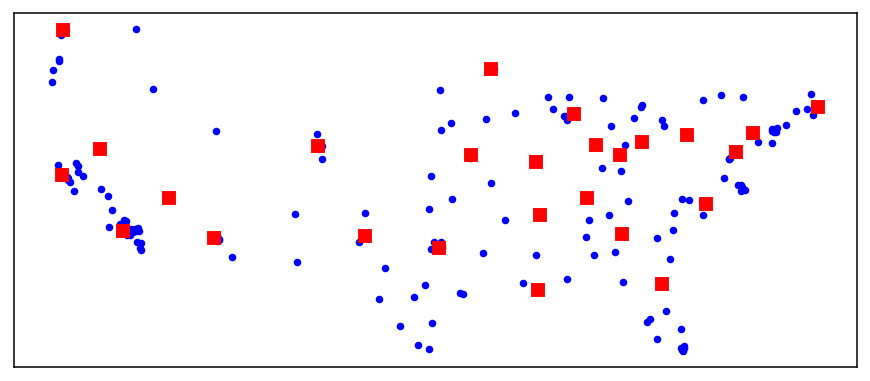

In [39]:
plot_map(customers=customers,
         warehouses=warehouses,
         warehouse_marker='s',
         warehouse_markercolor='red',
         warehouse_markersize=6,
         customer_marker='o',
         customer_markercolor='blue',
         customer_markersize=3)

A better map can be shown using the following command. However, this map allows only for the
visualization of location. To show the connections in the final solution you should use the plot_map command

In [7]:
show_geo_map(customers=customers, warehouses=warehouses, zoom=6)

Launch the solver's user interface

In [32]:
# test problem
warehouses = {
 1: Warehouse(name='Allentown', city='Allentown', state='PA', zipcode='18101', latitude=40.602812, longitude=-75.470433, capacity=500000, fixed_cost=1000),
 2: Warehouse(name='Atlanta', city='Atlanta', state='GA', zipcode='30301', latitude=33.753693, longitude=-84.389544, capacity=1000000, fixed_cost=2000),
 3: Warehouse(name='Baltimore', city='Baltimore', state='MD', zipcode='21201', latitude=39.294398, longitude=-76.622747, capacity=1500000, fixed_cost=3000),
 4: Warehouse(name='Boston', city='Boston', state='MA', zipcode='02101', latitude=42.36097, longitude=-71.05344, capacity=30000, fixed_cost=4000)
}

customers = {
 1: Customer(name='Akron', city='Akron', state='OH', zipcode='  ', latitude=41.08, longitude=-81.52, demand=205375),
 2: Customer(name='Albuquerque', city='Albuquerque', state='NM', zipcode='  ', latitude=35.12, longitude=-106.62, demand=535923),
 3: Customer(name='Alexandria', city='Alexandria', state='VA', zipcode='  ', latitude=38.82, longitude=-77.09, demand=147786),
 4: Customer(name='Amarillo', city='Amarillo', state='TX', zipcode='  ', latitude=35.2, longitude=-101.82, demand=190449),
 5: Customer(name='Anaheim', city='Anaheim', state='CA', zipcode='  ', latitude=33.84, longitude=-117.87, demand=342336),
 6: Customer(name='Brownfield', city='Brownfield', state='TX', zipcode='  ', latitude=33.18101, longitude=-102.27066, demand=283690),
 7: Customer(name='Arlington', city='Arlington', state='TX', zipcode='  ', latitude=32.69, longitude=-97.13, demand=385024),
 8: Customer(name='Arlington', city='Arlington', state='VA', zipcode='  ', latitude=38.88, longitude=-77.1, demand=214890),
 9: Customer(name='Atlanta', city='Atlanta', state='GA', zipcode='  ', latitude=33.76, longitude=-84.42, demand=571861)
}

distance = calculate_dm(warehouses=warehouses, customers=customers)

show_geo_map(warehouses=warehouses, customers=customers)

In [10]:
d = [c.demand for c in customers.values()]
sum(d)

2877334

In [10]:
from netopt_ui import netopt_ui
netopt_ui(warehouses, customers, distance)

Button(button_style='success', description='Solve', style=ButtonStyle())

Output()

In [10]:
from netopt_compat import netopt


Creating p-median optimizer...
Model's characteristics:
- Multi-sourcing model.
- Capacitated model.
- Objective function: minimize total cost
- Include warehouses' fixed costs

SOLVING (time limit = 120 seconds)...OK
==> Optimization Status: Optimal  (0.05 tolerance)<==
P-Median optimization results:
Minimum total cost (fixed + transportation): 2053724217
Open warehouses: (8 out of 26)
ID:   1 City: Allentown            State: PA     Num. customers:  33  Outflow:    17951659 units
ID:   5 City: Chicago              State: IL     Num. customers:  31  Outflow:    13042146 units
ID:   8 City: Dallas               State: TX     Num. customers:  35  Outflow:    13677157 units
ID:  11 City: Jacksonville         State: FL     Num. customers:  25  Outflow:     6553268 units
ID:  14 City: Los Angeles          State: CA     Num. customers:  36  Outflow:    12624357 units
ID:  19 City: Phoenix              State: AZ     Num. customers:  17  Outflow:     6940515 units
ID:  23 City: San Francisco 

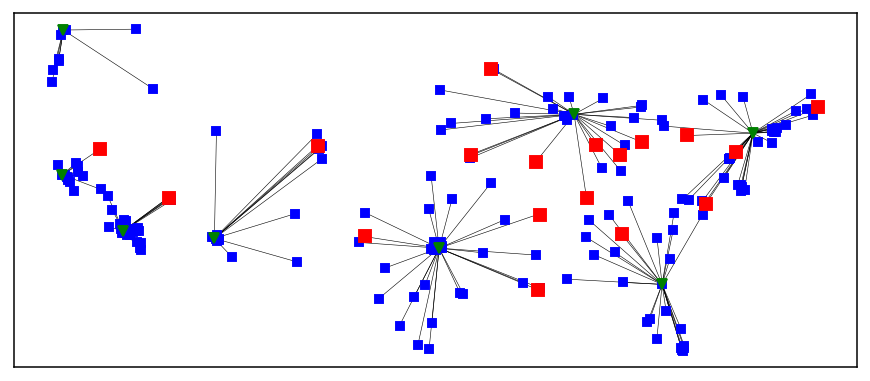

{'status': 'Optimal',
 'objective_value': 2053724217.211519,
 'avg_weighted_distance': 263.2091164929564,
 'active_warehouses_id': {1, 5, 8, 11, 14, 19, 23, 24},
 'active_warehouses_name': ['Allentown',
  'Chicago',
  'Dallas',
  'Jacksonville',
  'Los Angeles',
  'Phoenix',
  'San Francisco',
  'Seattle'],
 'most_distant_customer': 1004.7679598641579,
 'demand_perc_by_ranges': {(0, 99999): 1.0},
 'avg_customer_distance': 317.2137755468615,
 'multi_sourced_customers': [],
 'customers_assignment': [{'Warehouse': 'Jacksonville',
   'Warehouse_id': 11,
   'Customer': 'Saint Petersburg',
   'Customer_id': 158,
   'Customer Demand': 243829,
   'Distance': 301.35073246519187,
   'Warehouse Latitude': 30.32769,
   'Warehouse Longitude': -81.64815,
   'Customers Latitude': 27.76,
   'Customers Longitude': -82.64,
   'Flow': 243829.0},
  {'Warehouse': 'Allentown',
   'Warehouse_id': 1,
   'Customer': 'Jersey City',
   'Customer_id': 86,
   'Customer Demand': 242594,
   'Distance': 119.572594106

In [11]:
netopt(
        num_warehouses=8,
        factories=None,
        warehouses=warehouses,
        customers=customers,
        distance=distance,
        distance_ranges=[],
        objective="p-median",
        objective_function="mincost",
        high_service_distance=1000,
        unit_transport_cost= 0.1,
        mutually_exclusive=[],
        plot=True,
        plot_size= (8, 12),
        hide_inactive=False,
        force_single_sourcing=False,
        force_uncapacitated=False,
        ignore_fixed_cost=False,
        force_open=[],
        force_closed=[],
        force_allocations=[],
        warehouse_marker="s",
        warehouse_markercolor="red",
        warehouse_markersize=6,
        customer_marker="s",
        customer_markercolor="blue",
        customer_markersize=4,
        print_model=True
    )

**Get the optmimal location of num_warehouses warehouses**

You can change the value of parameter num_warehouses to test different scenario.
The parameter warehouses, customers, and distance are loaded in the previous cell.
You must define the objective: the objective mindistance minimizes the average weighted distance.
By setting the parameter plot to True, the function returns a simplyfied picture of the solution along with a summary of the performance. 
If you don't want the picture, set plot to False.

If you set hide_inactive to True the plot would not show inactive warehouses.
Outflow in the results represents the quantity exiting from each warehouse.


In [15]:
results = netopt(num_warehouses=5,  # this is the p parameter in the p-median problem
                 objective='mindistance',
                 warehouses=warehouses,
                 customers=customers,
                 distance=distance,
                 plot=True,
                 hide_inactive=True,
                 warehouse_marker='s',
                 warehouse_markercolor='red',
                 warehouse_markersize=6,
                 warehouse_active_markersize=12,
                 customer_marker='o',
                 customer_markercolor='blue',
                 customer_markersize=1)

TypeError: create_network_optimizer() missing 1 required positional argument: 'objective_function'

**Service levels**

By adding the parameter distance_ranges the functions returns the % of the demand within the passed distance ranges. 
For example, if distance_ranges = [0, 100, 200] the functions return the percentage of demand in the ranges [0, 100], (100, 200], (200, 99999]
where 99999 is used to represent a very long distance (i.e. infinite distance).

By changing the parameter num_warehouses and distance_ranges you can test different scenarios.
The parameter distance_ranges must be a list of increasing numbers. If you do not pass 0 as the first value
it will be automatically added


In [16]:
results = netopt(num_warehouses=10,
                 objective='mindistance',
                 warehouses=warehouses,
                 customers=customers,
                 distance=distance,
                 distance_ranges=[0, 100, 400, 800, 3200],
                 plot=True,
                 hide_inactive=True,
                 warehouse_marker='s',
                 warehouse_markercolor='red',
                 warehouse_markersize=6,
                 warehouse_active_markersize=12,
                 customer_marker='o',
                 customer_markercolor='blue',
                 customer_markersize=1)

TypeError: create_network_optimizer() missing 1 required positional argument: 'objective_function'

The results variable contains a summary of the optimization report

For a slightly better visualization of the results use print_solution as follows

In [ ]:
print_solution(results)

**Force warehouses open or close**

It is also possible to force warehouses to be open (for example, to force using the current warehouse)
or closed (to avoid the selection of some candidates).

The warehouses are references through their id, and must be passed as list [] (even for a single value, that is
to force closed the warehouse with id 1 you should pass force_closed=[1])

The id of the warehouses can be found in the 'warehouses' variable using the *show_data()* method.


In [ ]:
show_data(warehouses)

In [ ]:
results = netopt(num_warehouses=3,
                 objective='mindistance',
                 warehouses=warehouses,
                 customers=customers,
                 distance=distance,
                 force_open=[1],
                 force_closed=[8, 3],
                 distance_ranges=[0, 100, 400, 800, 3200],
                 plot=True,
                 hide_inactive=True,
                 warehouse_marker='s',
                 warehouse_markercolor='red',
                 warehouse_markersize=6,
                 warehouse_active_markersize=12,
                 customer_marker='o',
                 customer_markercolor='blue',
                 customer_markersize=1)

**Mutually exclusive facilities**

In some cases, some facilities may be _mutually exclusive_, that is the presence of one facility excludes the activation of a subset of other facilities.

For example, let's assume that facilities 1, 14 and 15 (i.e. tha facilities in the solution of the previous cell) are mutually exclusive (either one of them or none of them can be selected). This can be formulated by passing the parameter

_mutually_exclusive = [(1, 14, 15)]_


In [ ]:
results = netopt(num_warehouses=3,
                 objective='mindistance',
                 warehouses=warehouses,
                 customers=customers,
                 distance=distance,
                 force_open=[1],
                 force_closed=[8, 3],
                 distance_ranges=[0, 100, 400, 800, 3200],
                 mutually_exclusive=[(1, 14, 15)],
                 plot=True,
                 hide_inactive=True,
                 warehouse_marker='s',
                 warehouse_markercolor='red',
                 warehouse_markersize=6,
                 warehouse_active_markersize=12,
                 customer_marker='o',
                 customer_markercolor='blue',
                 customer_markersize=1)

It is possible to set any number of mutually exclusive sets (each set is a tuple in a list). For example:

_mutually_exclusive = [(1, 14, 15), (3, 4), (5, 6, 9, 11)]_

This constraint is useful when we have different alternatives (for example, different sizes) for the same facility.

**Covering problem**

The objective maxcover maximises the % of demand within a distance specified by the high_service_distance parameter. 
If you set the objective to maxcover and don't specify the high_service_distance parameter you'll get an error.

You should also set hide_flows to True to avoid the display of the allocations of customers to warehouses.

In [ ]:
results = netopt(num_warehouses=5,
                 objective='maxcover',
                 warehouses=warehouses,
                 customers=customers,
                 distance=distance,
                 high_service_distance=800,
                 avg_service_distance=5000,
                 distance_ranges=[0, 100, 400, 800, 3200],
                 force_open=[],
                 force_closed=[],
                 plot=True,
                 hide_inactive=True,
                 hide_flows=True,
                 warehouse_marker='s',
                 warehouse_markercolor='red',
                 warehouse_markersize=6,
                 warehouse_active_markersize=12,
                 customer_marker='o',
                 customer_markercolor='blue',
                 customer_markersize=1)

#print_solution(results)


If you know a little bit of python (or you are willing to learn a little bit), 
you can easily automate experiments.
For example, compute the average weighted distance for several values of *p*


In [ ]:
for p in [1, 2, 3, 4, 5]:
    results = netopt(num_warehouses=p,
                 objective='mindistance',
                 warehouses=warehouses,
                 customers=customers,
                 distance=distance,
                 force_open=[],
                 force_closed=[],
                 plot=False)
    print()
    print(f"*** AVG WEIGHTED DISTANCE FOR p={p}: {results['avg_weighted_distance']} ***")
    print()


You can collect data from different experiments and the plot it.

In [ ]:
data = {}
for p in [1, 2, 3, 4, 5]:
    results = netopt(num_warehouses=p,
                 objective='mindistance',
                 warehouses=warehouses,
                 customers=customers,
                 distance=distance,
                 force_open=[],
                 plot=False)
    data[p] = results['avg_weighted_distance']
    
# Plot the results
import matplotlib.pyplot as plt
plt.plot(data.keys(), data.values())

# Adding capacity #

Import the data for the problem with capacities

In [ ]:
from data.scenario_5 import warehouses, customers

Compute the distance matrix

In [ ]:
distance = calculate_dm(warehouses, customers, use_haversine=True)

In [ ]:
show_geo_map(customers=customers, warehouses=warehouses, zoom=4)

Solve a p-median problem excluding the capacities: since the warehouses have the *capacity* attributes set, we need to instruct the solver to skip such an attribute in solvgin the problem by settin *force_uncapacitated=True*).

In [ ]:
results = netopt(num_warehouses=5,
                 warehouses=warehouses,
                 customers=customers,
                 distance=distance,
                 objective='mindistance',
                 force_uncapacitated=True,
                 distance_ranges=[0, 800, 1200],
                 plot=True,
                 warehouse_markersize=5,
                 warehouse_active_markersize=8,
                hide_inactive=True)
print_dict(results)

We would like to spread the quantity more evenly
Let's limit the capacity of the five warehouses to 1/5 of the total demand

In [ ]:
set_all_capacities(warehouses, 20_000_000)

Solve again a mindistance problem with capacities, enforcing the single sourcing constraint. This constraint is implicit, you don't need to change anything.

In [ ]:
results = netopt(num_warehouses=5,
                 warehouses=warehouses,
                 customers=customers,
                 distance=distance,
                 objective='mindistance',
                 force_uncapacitated=False,
                 distance_ranges=[0, 800, 1200],
                 plot=True,
                 warehouse_markersize=5,
                 warehouse_active_markersize=8)
print_dict(results)

The model in **infeasible** that is there is no solution.

Let's increase the capacity of all warehouses to 30.000.000 units and solve again.

In [ ]:
set_all_capacities(warehouses, 30_000_000)

results = netopt(num_warehouses=5,
                 warehouses=warehouses,
                 customers=customers,
                 distance=distance,
                 objective='mindistance',
                 force_uncapacitated=False,
                 hide_inactive=True,
                 distance_ranges=[0, 800, 1200],
                 plot=True,
                 warehouse_markersize=5,
                 warehouse_active_markersize=8)
print_dict(results)

Now the model is feasible

**Remove the single-source constraint**

The model implicitly stipulates the single-source constraint (each customer is served by exactly one warehouse).
When dealing with capacities, it may be useful to relax this constraint to better exploit the available capacity.

To relax the single-source constraint set *force_single_sourcing=False*

We try solving again with capacity equal to 20.000.000 for all warehouses and no single-source constraint.

In [ ]:
set_all_capacities(warehouses, 20_000_000)

results = netopt(num_warehouses=5,
                 warehouses=warehouses,
                 customers=customers,
                 distance=distance,
                 objective='mindistance',
                 distance_ranges=[0, 800, 1200],
                 force_single_sourcing=False,
                 plot=True,
                 hide_inactive=True,
                 warehouse_markersize=5,
                 warehouse_active_markersize=8)
print_dict(results)

Now the model is feasible

**Feel free to play with the parameters. If you find any error, please report it to me.**

In [ ]:
import ipywidgets as widgets

In [ ]:
button = widgets.Button(description="Click Me!")
output = widgets.Output()


In [ ]:
display(button, output)

In [ ]:
def on_button_clicked(b):
    with output:
        print("Button clicked.")

button.on_click(on_button_clicked)

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Define widgets ---
num_wh = widgets.IntSlider(
    description="# Warehouses", min=1, max=20, step=1, value=3
)

warehouses = widgets.Textarea(
    description="Warehouses", 
    placeholder="e.g. ['W1','W2','W3']",
    layout=widgets.Layout(width='400px', height='60px')
)

customers = widgets.Textarea(
    description="Customers",
    placeholder="e.g. ['C1','C2','C3','C4']",
    layout=widgets.Layout(width='400px', height='60px')
)

distance = widgets.Textarea(
    description="Distance",
    placeholder="e.g. [[10,20,30],[5,15,25],[8,18,28]]",
    layout=widgets.Layout(width='400px', height='80px')
)

distance_ranges = widgets.Text(
    description="Dist. Ranges",
    placeholder="e.g. [0,10,20,30]"
)

objective = widgets.Dropdown(
    options=['', 'min_cost', 'max_service', 'custom'],
    description="Objective"
)

high_sd = widgets.FloatText(
    description="High svc dist", value= None
)

avg_sd = widgets.FloatText(
    description="Avg svc dist", value=None
)

max_sd = widgets.FloatText(
    description="Max svc dist", value=None
)

force_open = widgets.Text(
    description="Force open",
    placeholder="e.g. [0,2]"
)

force_closed = widgets.Text(
    description="Force closed",
    placeholder="e.g. [1]"
)

force_single = widgets.Checkbox(
    description="Single sourcing", value=True
)

force_uncap = widgets.Checkbox(
    description="Uncapacitated", value=False
)

force_alloc = widgets.Text(
    description="Force allocs",
    placeholder="e.g. [(0,1),(2,3)]"
)

ignore_fc = widgets.Checkbox(
    description="Ignore fixed cost", value=False
)

plot = widgets.Checkbox(
    description="Show plot", value=True
)

plot_size = widgets.Text(
    description="Plot size",
    placeholder="e.g. (8,12)"
)

hide_inactive = widgets.Checkbox(
    description="Hide inactive", value=False
)

hide_flows = widgets.Checkbox(
    description="Hide flows", value=False
)

solver_log = widgets.Checkbox(
    description="Solver log", value=False
)

unit_cost = widgets.FloatText(
    description="Unit transport cost", value=0.1
)

mut_excl = widgets.Text(
    description="Mutually excl.",
    placeholder="e.g. [(0,1),(2,3)]"
)

run_button = widgets.Button(description="Run netopt", button_style='success')
out = widgets.Output()

# --- Helper to safely eval widget text ---
def parse(text):
    try:
        return eval(text) if text.strip() else None
    except Exception as e:
        raise ValueError(f"Could not parse `{text}`: {e}")

# --- Callback ---
def on_run(b):
    with out:
        clear_output()
        try:
            params = {
                "num_warehouses": num_wh.value,
                "warehouses": parse(warehouses.value),
                "customers": parse(customers.value),
                "distance": parse(distance.value),
                "distance_ranges": parse(distance_ranges.value),
                "objective": objective.value,
                "high_service_distance": high_sd.value or None,
                "avg_service_distance": avg_sd.value or None,
                "max_service_distance": max_sd.value or None,
                "force_open": parse(force_open.value),
                "force_closed": parse(force_closed.value),
                "force_single_sourcing": force_single.value,
                "force_uncapacitated": force_uncap.value,
                "force_allocations": parse(force_alloc.value),
                "ignore_fixed_cost": ignore_fc.value,
                "plot": plot.value,
                "plot_size": parse(plot_size.value) or (8,12),
                "hide_inactive": hide_inactive.value,
                "hide_flows": hide_flows.value,
                "solver_log": solver_log.value,
                "unit_transport_cost": unit_cost.value,
                "mutually_exclusive": parse(mut_excl.value),
            }
            # call your function
            result = netopt(**params)
            print("Result:", result)
        except Exception as e:
            print("Error:", e)

run_button.on_click(on_run)

# --- Layout & display ---
left = widgets.VBox([
    num_wh, warehouses, customers, distance, distance_ranges,
    objective, high_sd, avg_sd, max_sd, force_open, force_closed,
    force_single, force_uncap, force_alloc, ignore_fc,
    plot, plot_size, hide_inactive, hide_flows, solver_log,
    unit_cost, mut_excl,
])
ui = widgets.HBox([left])
display(ui, run_button, out)


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from ipywidgets import GridspecLayout

# --- Define widgets (same as before) ---
num_wh = widgets.IntSlider(description="# Warehouses", min=1, max=20, value=3)
# warehouses = widgets.Textarea(description="Warehouses", placeholder="e.g. ['W1','W2','W3']")
# customers  = widgets.Textarea(description="Customers",  placeholder="e.g. ['C1','C2','C3']")
# distance   = widgets.Textarea(description="Distance",   placeholder="e.g. [[10,20],[5,15]]")
distance_ranges = widgets.Text(description="Distance ranges", placeholder="e.g. [0, 10, 20]")
objective  = widgets.Dropdown(options=['mindistance','max_cover'], description="Objective")
high_sd    = widgets.FloatText(description="High svc dist")
avg_sd     = widgets.FloatText(description="Avg svc dist")
max_sd     = widgets.FloatText(description="Max svc dist")
unit_cost  = widgets.FloatText(description="Unit cost", value=0.1)
force_open    = widgets.Text(description="Force open",   placeholder="e.g. [0,2]")
force_closed  = widgets.Text(description="Force closed", placeholder="e.g. [1]")
force_alloc   = widgets.Text(description="Force allocs", placeholder="e.g. [(0,1)]")
mut_excl      = widgets.Text(description="Mut. excl.",    placeholder="e.g. [(0,1)]")
force_single  = widgets.Checkbox(description="Single sourcing", value=True)
force_uncap   = widgets.Checkbox(description="Uncapacitated",   value=False)
ignore_fc     = widgets.Checkbox(description="Ignore fixed cost")
plot          = widgets.Checkbox(description="Show plot", value=True)
plot_size     = widgets.Text(description="Plot size", placeholder="e.g. (8,12)")
hide_inactive = widgets.Checkbox(description="Hide inactive")
hide_flows    = widgets.Checkbox(description="Hide flows")
solver_log    = widgets.Checkbox(description="Solver log")

run_button = widgets.Button(description="Run netopt", button_style='success')
out = widgets.Output()

# --- parse helper ---
def parse(txt):
    return eval(txt) if txt.strip() else None

# --- callback ---
def on_run(_):
    with out:
        clear_output()
        try:
            params = {
                "num_warehouses": num_wh.value,
                "warehouses": warehouses,
                "customers": customers,
                "distance": distance,
                "distance_ranges": parse(distance_ranges.value),
                "objective": objective.value,
                "high_service_distance": high_sd.value or None,
                "avg_service_distance": avg_sd.value or None,
                "max_service_distance": max_sd.value or None,
                "force_open": parse(force_open.value),
                "force_closed": parse(force_closed.value),
                "force_single_sourcing": force_single.value,
                "force_uncapacitated": force_uncap.value,
                "force_allocations": parse(force_alloc.value),
                "ignore_fixed_cost": ignore_fc.value,
                "plot": plot.value,
                "plot_size": parse(plot_size.value) or (8,12),
                "hide_inactive": hide_inactive.value,
                "hide_flows": hide_flows.value,
                "solver_log": solver_log.value,
                "unit_transport_cost": unit_cost.value,
                "mutually_exclusive": parse(mut_excl.value),
            }
            print(params["mutually_exclusive"])
            result = netopt(**params)
            print("Result:", result)
        except Exception as e:
            print("Error:", e)

run_button.on_click(on_run)

# --- build an 8×4 grid ---
grid = GridspecLayout(8, 4, width='100%')

# Row 0
grid[0, 0] = num_wh
grid[0, 1] = objective
grid[0, 2] = force_single
grid[0, 3] = force_uncap

# Row 1 (span 2 cols each)
#grid[1, 0:2] = warehouses
#grid[1, 2:4] = customers

# Row 2
#grid[2, 0:2] = distance
grid[2, 2:4] = distance_ranges

# Row 3
grid[3, 0] = high_sd
grid[3, 1] = avg_sd
grid[3, 2] = max_sd
grid[3, 3] = unit_cost

# Row 4
grid[4, 0] = force_open
grid[4, 1] = force_closed
grid[4, 2] = force_alloc
grid[4, 3] = mut_excl

# Row 5
grid[5, 0] = ignore_fc
grid[5, 1] = plot
grid[5, 2] = plot_size
grid[5, 3] = hide_inactive

# Row 6
grid[6, 0] = hide_flows
grid[6, 1] = solver_log

# Row 7: run button spans all columns
grid[7, 0:4] = run_button

# --- display everything ---
display(grid, out)


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. Define all your widgets ---
num_wh = widgets.IntSlider(description="# Warehouses", min=1, max=20, value=3)
#warehouses = widgets.Textarea(description="Warehouses", placeholder="['W1','W2','W3']")
#customers  = widgets.Textarea(description="Customers",  placeholder="['C1','C2','C3']")
#distance   = widgets.Textarea(description="Distance",   placeholder="[[10,20],[5,15]]")
distance_ranges = widgets.Text(description="Dist. Ranges", placeholder="[0,10,20]")

objective  = widgets.Dropdown(options=['','mindistance','maxcover'], description="Objective")
high_sd    = widgets.FloatText(description="High svc dist")
avg_sd     = widgets.FloatText(description="Avg svc dist")
max_sd     = widgets.FloatText(description="Max svc dist")
unit_cost  = widgets.FloatText(description="Unit cost", value=0.1)

force_open   = widgets.Text(description="Force open",   placeholder="[0,2]")
force_closed = widgets.Text(description="Force closed", placeholder="[1]")
force_alloc  = widgets.Text(description="Force allocs", placeholder="[(0,1)]")
mut_excl     = widgets.Text(description="Mut. excl.",    placeholder="[(0,1)]")
force_single = widgets.Checkbox(description="Single sourcing", value=True)
force_uncap  = widgets.Checkbox(description="Uncapacitated",   value=False)

ignore_fc     = widgets.Checkbox(description="Ignore fixed cost")
plot          = widgets.Checkbox(description="Show plot", value=True)
plot_size     = widgets.Text(description="Plot size", placeholder="(8,12)")
hide_inactive = widgets.Checkbox(description="Hide inactive")
hide_flows    = widgets.Checkbox(description="Hide flows")
solver_log    = widgets.Checkbox(description="Solver log")

run_button = widgets.Button(description="Run netopt", button_style='success')
out = widgets.Output()

# --- 2. Simple eval helper ---
def parse(txt):
    return eval(txt) if txt.strip() else None

# --- 3. Callback to call netopt ---
def on_run(_):
    with out:
        clear_output()
        try:
            params = {
                "num_warehouses": num_wh.value,
                "warehouses": warehouses,
                "customers": customers,
                "distance": distance,
                "distance_ranges": parse(distance_ranges.value),
                "objective": objective.value,
                "high_service_distance": high_sd.value or None,
                "avg_service_distance": avg_sd.value or None,
                "max_service_distance": max_sd.value or None,
                "force_open": parse(force_open.value),
                "force_closed": parse(force_closed.value),
                "force_single_sourcing": force_single.value,
                "force_uncapacitated": force_uncap.value,
                "force_allocations": parse(force_alloc.value),
                "ignore_fixed_cost": ignore_fc.value,
                "plot": plot.value,
                "plot_size": parse(plot_size.value) or (8,12),
                "hide_inactive": hide_inactive.value,
                "hide_flows": hide_flows.value,
                "solver_log": solver_log.value,
                "unit_transport_cost": unit_cost.value,
                "mutually_exclusive": parse(mut_excl.value),
            }
            result = netopt(**params)
            print("Result:", result)
        except Exception as e:
            print("Error:", e)

run_button.on_click(on_run)

# --- 4. Build three columns ---
sec_layout = widgets.Layout(border='1px solid #ddd', padding='10px', margin='5px', width='30%')

# Section 1: General parameters
sec1 = widgets.VBox([
    widgets.HTML("<h4>General</h4>"),
    num_wh, warehouses, customers, distance, distance_ranges, objective
], layout=sec_layout)

# Section 2: Constraints
sec2 = widgets.VBox([
    widgets.HTML("<h4>Constraints</h4>"),
    high_sd, avg_sd, max_sd, unit_cost,
    force_open, force_closed, force_alloc, mut_excl,
    force_single, force_uncap
], layout=sec_layout)

# Section 3: Display & run
sec3 = widgets.VBox([
    widgets.HTML("<h4>Display & Run</h4>"),
    ignore_fc, plot, plot_size,
    hide_inactive, hide_flows, solver_log,
    run_button
], layout=sec_layout)

# Combine into one HBox
ui = widgets.HBox([sec1, sec2, sec3])
display(ui, out)


In [ ]:
warehouses

In [ ]:
type(distance)


In [ ]:
distance

In [ ]:
customers

In [2]:
import pandas as pd
from data_structures import Warehouse, Customer, show_geo_map, show_data
from netopt_ui import netopt_ui


In [3]:
df_warehouses = pd.read_excel("D:\\Dropbox\\WorkingFolder\\Courses\\SCMLND\\Project Work\\2024-2025\\de-cities.xlsx", sheet_name="Warehouses")
df_customers = pd.read_excel("D:\\Dropbox\\WorkingFolder\\Courses\\SCMLND\\Project Work\\2024-2025\\de-cities.xlsx", sheet_name="Customers")


In [4]:
from math import radians, cos, sin, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

In [5]:
import numpy as np

def select_well_distributed_cities(cities, N):
    M = len(cities)
    # selected = [np.random.randint(M)]
    selected = [0]
    while len(selected) < N:
        best_city = None
        best_min_dist = -1
        for i in range(M):
            if i in selected:
                continue
            min_dist = min(
                haversine(cities.loc[i].lat, cities.loc[i].lng, cities.loc[j].lat, cities.loc[j].lng)
                for j in selected
            )
            if min_dist > best_min_dist:
                best_min_dist = min_dist
                best_city = i
        selected.append(best_city)
    return selected

In [6]:
selected = select_well_distributed_cities(df_warehouses, 14)

In [8]:
warehouses = {}
for n, each in enumerate(selected):
    # print(df.loc[each])
    city = df_warehouses.loc[each]
    warehouses[n] = Warehouse(name=city.city, city=city.city, state="Germany", zipcode="", latitude=city.lat, longitude=city.lng, capacity=city.capacity, fixed_cost=city.fixed_cost)

In [9]:
customers = {}
max_num_customers = 80

for n, each in df_customers.iterrows():
    if n > max_num_customers:
        break    
    customers[n] = Customer(name=each.city, city=each.city, state='Germany', zipcode='  ', latitude=each.lat, longitude=each.lng, demand=each.demand)
    

In [10]:
show_geo_map(warehouses=warehouses, customers=customers, zoom= 6)

In [28]:
netopt_ui(warehouses=warehouses, customers=customers)

Button(button_style='success', description='Solve', style=ButtonStyle())

Output()

In [13]:
show_data(warehouses)

|    |   Id | Identifier   | City        |   Latitude |   Longitude |   Capacity |   Yearly fixed cost |
|---:|-----:|:-------------|:------------|-----------:|------------:|-----------:|--------------------:|
|  0 |    0 | Berlin       | Berlin      |    52.52   |     13.405  |     183609 |              692864 |
|  1 |    1 | Merzhausen   | Merzhausen  |    47.9664 |      7.8286 |     125839 |              474864 |
|  2 |    2 | Herten       | Herten      |    51.6    |      7.1333 |      96352 |              363592 |
|  3 |    3 | Flensburg    | Flensburg   |    54.7819 |      9.4367 |     109857 |              207277 |
|  4 |    4 | Regensburg   | Regensburg  |    49.0167 |     12.0833 |     138089 |              390818 |
|  5 |    5 | Darmstadt    | Darmstadt   |    49.8722 |      8.6528 |     141742 |              267438 |
|  6 |    6 | Jena         | Jena        |    50.9272 |     11.5861 |     161220 |              456283 |
|  7 |    7 | Hannover     | Hannover    |    52.3667 |

In [27]:
from netopt_ui import netopt_ui, edit_warehouse, add_warehouse, delete_warehouse

In [ ]:
warehouses[2]

In [ ]:
warehouses[14] = Warehouse(name='Herten_expanded', city='Herten', state='Germany', zipcode='', latitude=np.float64(51.6), longitude=np.float64(7.1333), capacity=np.int64(110000), fixed_cost=np.int64(363592))

In [ ]:
warehouses

In [ ]:
show_data(warehouses)

In [ ]:
from netopt_ui import edit_warehouse, add_warehouse, delete_warehouse

In [ ]:
edit_warehouse(warehouses=warehouses, warehouse_id=13)

In [ ]:
delete_warehouse(warehouses=warehouses)

In [ ]:
show_data(warehouses)

In [ ]:
add_warehouse(warehouses=warehouses)

In [30]:
customers

{0: Customer(name='Berlin', city='Berlin', state='Germany', zipcode='  ', latitude=52.52, longitude=13.405, demand=60440),
 1: Customer(name='Stuttgart', city='Stuttgart', state='Germany', zipcode='  ', latitude=48.7775, longitude=9.18, demand=32700),
 2: Customer(name='Munich', city='Munich', state='Germany', zipcode='  ', latitude=48.1375, longitude=11.575, demand=35857),
 3: Customer(name='Hamburg', city='Hamburg', state='Germany', zipcode='  ', latitude=53.55, longitude=10.0, demand=27490),
 4: Customer(name='Cologne', city='Cologne', state='Germany', zipcode='  ', latitude=50.9364, longitude=6.9528, demand=17537),
 5: Customer(name='Frankfurt', city='Frankfurt', state='Germany', zipcode='  ', latitude=50.1106, longitude=8.6822, demand=11246),
 6: Customer(name='Düsseldorf', city='Düsseldorf', state='Germany', zipcode='  ', latitude=51.2333, longitude=6.7833, demand=10162),
 7: Customer(name='Leipzig', city='Leipzig', state='Germany', zipcode='  ', latitude=51.34, longitude=12.375,